# Part 2

In [1]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import scipy

## Task 7

In [2]:
Q = np.array([[-0.0085,0.005,0.0025,0,0.001],
                  [0,-0.014,0.005,0.004,0.005],
                  [0,0,-0.008,0.003,0.005],
                  [0,0,0,-0.009,0.009],
                  [0,0,0,0,0]])

N,_ = Q.shape

states = np.arange(1,N+1)

In [3]:
#Initially, all in state 1

#Time in state 1
t_state = np.random.exponential(scale = 1/-Q[0][0])

#Probabilities for jumping to next states (1->2,1->3,1->4,1->5)
probs = np.array([-Q[0][1]/Q[0][0],-Q[0][2]/Q[0][0],-Q[0][3]/Q[0][0],-Q[0][4]/Q[0][0]])

print(np.sum(probs)) # Test if they sum to 1


1.0


In [4]:
s = 1

#Next state will be
s_pos = np.delete(states,s-1)

print(s_pos)

probs = []
for x in s_pos:
    probs.append(-Q[s-1][x-1]/Q[s-1][s-1])

print(probs)

probs = np.array([-Q[s-1][s]/Q[s-1][s-1],-Q[s-1][s+1]/Q[s-1][s-1],-Q[s-1][s+2]/Q[s-1][s-1],-Q[s-1][s+3]/Q[s-1][s-1]])
#s_next = np.random.choice(s_pos, p=probs)
print(probs)



[2 3 4 5]
[np.float64(0.5882352941176471), np.float64(0.29411764705882354), np.float64(0.0), np.float64(0.11764705882352941)]
[0.58823529 0.29411765 0.         0.11764706]


In [5]:
def contMarkov(Q):
    t = 0
    s = 1
    track = [(0,1)]
    while s != 5:
        t_sojourn = np.random.exponential(scale = 1/-Q[s-1][s-1])
        t += t_sojourn
        
        s_pos = np.delete(states,s-1)

        probs = []
        for x in s_pos:
            probs.append(-Q[s-1][x-1]/Q[s-1][s-1])

        s_next = int(np.random.choice(s_pos, p=probs))
        s = s_next

        track.append((t, s))

    return t,track

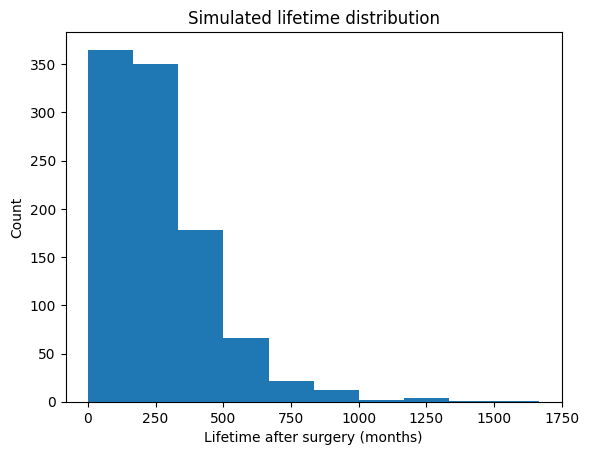

In [6]:
n_women = 1000

results = [contMarkov(Q) for i in range(n_women)]

lifetimes = np.array([t for t,track in results])
trackings = [track for t,track in results]

plt.hist(lifetimes)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Count")
plt.title("Simulated lifetime distribution")
plt.show()

In [16]:
lifetime_mean = np.mean(lifetimes)
lifetime_std = np.std(lifetimes,ddof=1)

alpha=0.05
p_quantile_1 = stats.t.ppf(q=alpha/2,df=n_women-1)
p_quantile_2 = stats.t.ppf(q=1-alpha/2,df=n_women-1)

CI_mean = [float(lifetime_mean + (lifetime_std/np.sqrt(n_women))*p_quantile_1),float(lifetime_mean + (lifetime_std/np.sqrt(n_women))*p_quantile_2)]

chi2_lower = stats.chi2.ppf(alpha/2, df=n_women-1)
chi2_upper = stats.chi2.ppf(1-alpha/2, df=n_women-1)

CI_std = [float(np.sqrt((n_women-1)*lifetime_std**2 / chi2_upper)), float(np.sqrt((n_women-1)*lifetime_std**2 / chi2_lower))]


print(lifetime_mean,CI_mean)
print(lifetime_std,CI_std)


264.6963233857765 [252.08182046623705, 277.31082630531597]
203.28042579066565 [194.7451582428789, 212.60395517145824]


In [8]:
t_distReap = 30.5

#The next time interpretation depends on the phrasing
#The phrasing is: "In what proportion of women has the cancer reappeared distantly after 30.5 months?"
#If they mean, how many women have experienced it BY 30.5 months, it should say time <= t_distReap
#If they mean, how many women experienced it AFTER 30.5 months, it should say time > t_distReap
n_distReap = sum(any(state in [3,4] and time <= t_distReap for time, state in tracking) for tracking in trackings)

prop_distReap = n_distReap / n_women

print(prop_distReap)

0.085


## Task 8

In [9]:
Q_s = np.array([[-0.0085,0.005,0.0025,0],
                  [0,-0.014,0.005,0.004],
                  [0,0,-0.008,0.003],
                  [0,0,0,-0.009]])

p_0 = np.array([1,0,0,0])

ones = np.array([1,1,1,1])

In [10]:
def F_T(t):
    return 1 - p_0 @ scipy.linalg.expm(Q_s*t) @ ones

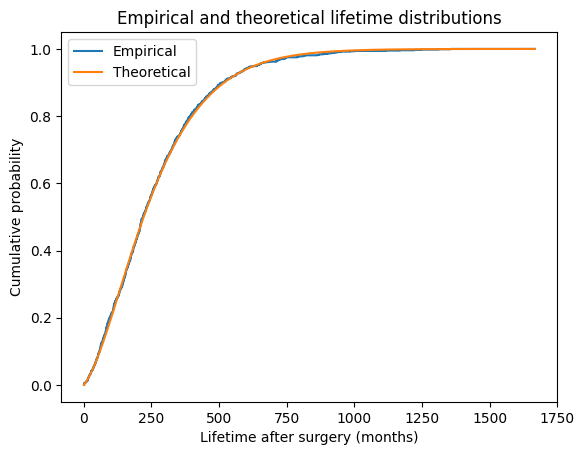

0.016698139144578017


In [17]:
T = np.linspace(0,max(lifetimes),n_women)
theory = np.array([F_T(t) for t in T])

#Manual:
lifetime_sorted = np.sort(lifetimes)
empiry = np.arange(1, n_women+1) / n_women

plt.step(lifetime_sorted,empiry, label="Empirical")
plt.plot(T, theory, label="Theoretical")
plt.legend()
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Cumulative probability")
plt.title("Empirical and theoretical lifetime distributions")
plt.show()

#Alternative:
#ecdf = stats.ecdf(lifetimes)

#plt.step(ecdf.cdf.quantiles,ecdf.cdf.probabilities, label="Empirical")
#plt.plot(T, theory, label="Theoretical")
#plt.legend()
#plt.show()


#KS-test:
#stats.kstest(lifetimes,F_T)

KS = stats.kstest(lifetimes,lambda t: np.array([F_T(x) for x in np.atleast_1d(t)]))
D = KS.statistic

print(D)

## Task 9

In [12]:
n1 = -sum([0.0025,0.00125,0,0.001])
n2 = -sum([0,0.002,0.005])
n3 = -sum([0.003,0.005])
n4 = -sum([0.009])

Q_T = np.array([[n1,0.0025,0.00125,0,0.001],
                  [0,n2,0,0.002,0.005],
                  [0,0,n3,0.003,0.005],
                  [0,0,0,n4,0.009],
                  [0,0,0,0,0]])

In [13]:
def d(t,tracking):
    count = 0
    for track in tracking:
        for time,state in track:
            if state == 5 and time < t:
                count += 1

    return count

def Kaplan_Meier(t,tracking):
    return (n_women - d(t,tracking))/n_women

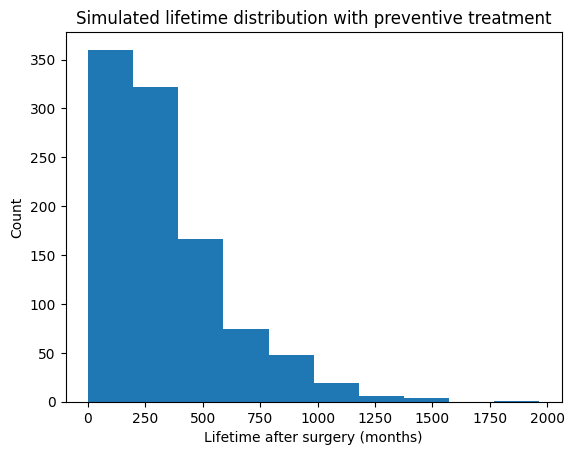

In [14]:
results_T = [contMarkov(Q_T) for i in range(n_women)]

lifetimes_T = np.array([t for t,track in results_T])
trackings_T = [track for t,track in results_T]

plt.hist(lifetimes_T)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Count")
plt.title("Simulated lifetime distribution with preventive treatment")
plt.show()

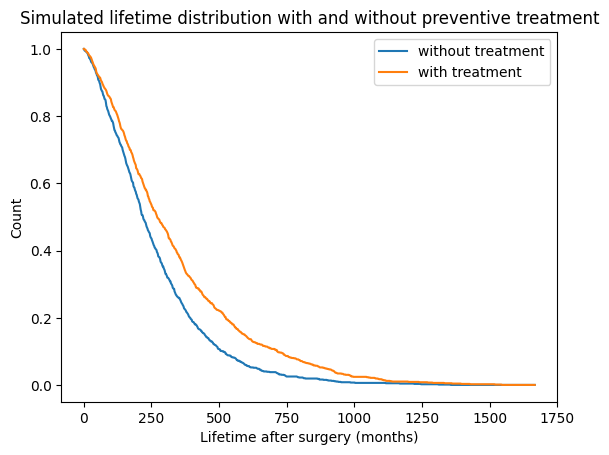

In [15]:
KM_Q = np.array([Kaplan_Meier(t,trackings) for t in T])
KM_Q_T = np.array([Kaplan_Meier(t,trackings_T) for t in T])

plt.plot(T,KM_Q,label="without treatment")
plt.plot(T,KM_Q_T,label="with treatment")
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Count")
plt.title("Simulated lifetime distribution with and without preventive treatment")
plt.legend()
plt.show()